# Lab 1: Iris Data Exploration and Visualization

This lab is an open-ended exploration of the Iris dataset. There is no single required sequence of analyses and no need to complete every section.

## Setup

Run these cells to import the packages and load the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
iris = pd.read_csv("data/iris.csv")
iris.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Become familiar with the dataset

Explore the structure and contents of the dataset.

Consider:

- What does one row represent?
- What does each column represent?
- Which attributes are numeric and which are categorical?
- How large is the dataset?
- Are any values missing?
- How many observations belong to each species?

In [3]:
iris.describe()


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check data types and missing values
print("Data types:")
print(iris.dtypes)
print("\nMissing values per column:")
print(iris.isnull().sum())

Data types:
sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

Missing values per column:
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64


## 2. Develop questions about the data

Write down questions that you could investigate.

Possible starting points:

- What are typical sepal and petal measurements for each species?
- Are there any possible outliers?
- Which attributes are related?
- Which attributes appear most useful for distinguishing species?
- What else would you like to learn from the data?

**Your questions:**

1. Are sepal and petal lengths correlated? 
2. What about sepal and petal widths?
3. What is the distribution of sepal and petal lengths per species? 

## 3. Explore individual attributes

Investigate one or more attributes on their own.

Consider typical values, variability, the shape of the distribution, possible unusual observations, and whether the results change when the species are considered separately.

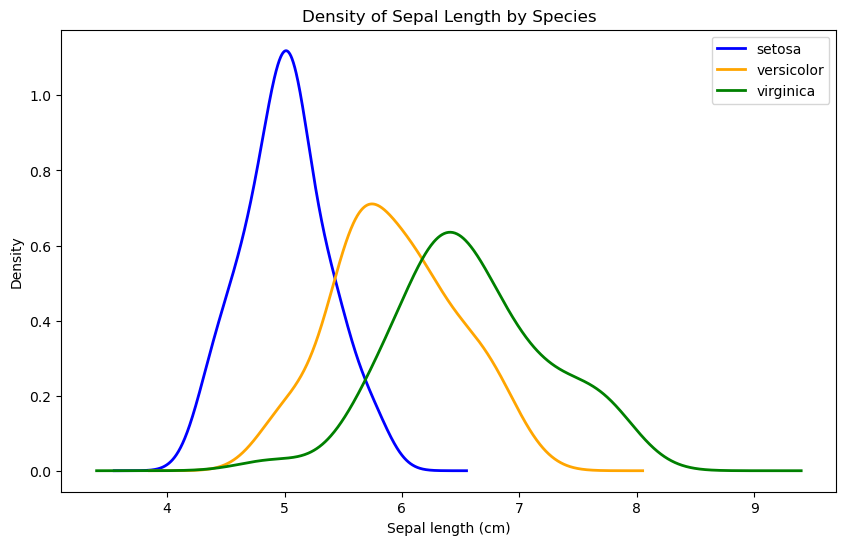

Sepal Length Analysis per Species

--- setosa ---
  Mode: [5.  5.1]
  Variance: 0.1242
  Skewness: 0.1201  (0 = symmetric, >0 right-skewed, <0 left-skewed)
  Kurtosis: -0.2527  (>0 leptokurtic, <0 platykurtic)
  IQR: 0.4000
  Lower bound: 4.2000, Upper bound: 5.8000
  Number of outliers: 0

--- versicolor ---
  Mode: [5.5 5.6 5.7]
  Variance: 0.2664
  Skewness: 0.1054  (0 = symmetric, >0 right-skewed, <0 left-skewed)
  Kurtosis: -0.5330  (>0 leptokurtic, <0 platykurtic)
  IQR: 0.7000
  Lower bound: 4.5500, Upper bound: 7.3500
  Number of outliers: 0

--- virginica ---
  Mode: [6.3]
  Variance: 0.4043
  Skewness: 0.1180  (0 = symmetric, >0 right-skewed, <0 left-skewed)
  Kurtosis: 0.0329  (>0 leptokurtic, <0 platykurtic)
  IQR: 0.6750
  Lower bound: 5.2125, Upper bound: 7.9125
  Number of outliers: 1
  Outlier values: [4.9]


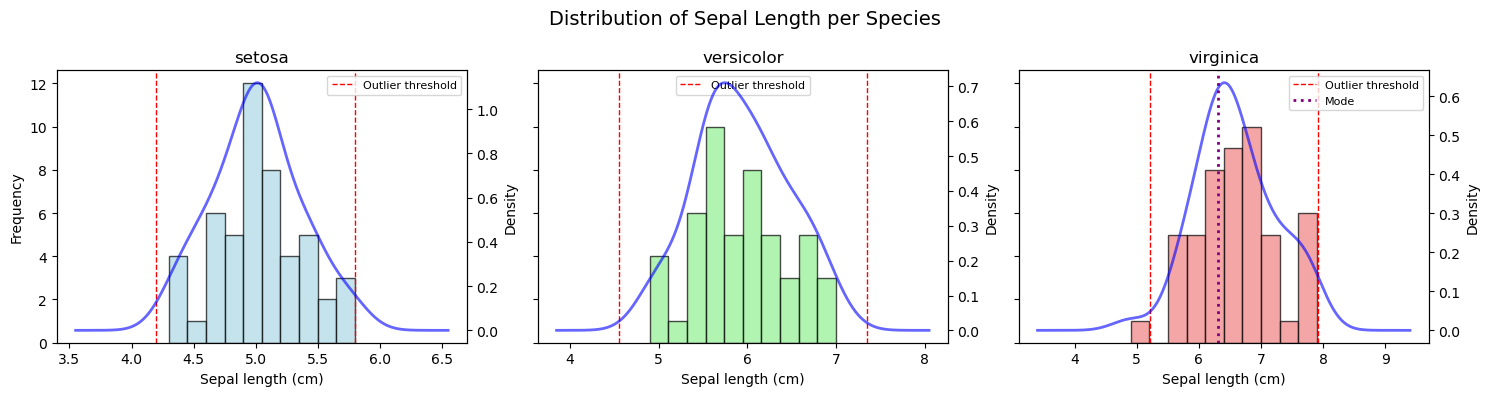

In [14]:
species = sorted(iris['species'].unique())

# Per-species density plots of sepal length
fig2, ax2 = plt.subplots(figsize=(10, 6))
colors_kde = ['blue', 'orange', 'green']
for sp, col in zip(species, colors_kde):
    iris.loc[iris['species'] == sp, 'sepal_length_cm'].plot(kind='kde', ax=ax2, label=sp, color=col, linewidth=2)
ax2.set_xlabel('Sepal length (cm)')
ax2.set_ylabel('Density')
ax2.set_title('Density of Sepal Length by Species')
ax2.legend()
plt.show()

print("=" * 60)
print("Sepal Length Analysis per Species")
print("=" * 60)

for sp in species:
    data = iris.loc[iris['species'] == sp, 'sepal_length_cm']
    print(f"\n--- {sp} ---")
    print(f"  Mode: {data.mode().values}")
    print(f"  Variance: {data.var():.4f}")
    print(f"  Skewness: {data.skew():.4f}  (0 = symmetric, >0 right-skewed, <0 left-skewed)")
    print(f"  Kurtosis: {data.kurtosis():.4f}  (>0 leptokurtic, <0 platykurtic)")

    # Outliers using IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"  IQR: {iqr:.4f}")
    print(f"  Lower bound: {lower_bound:.4f}, Upper bound: {upper_bound:.4f}")
    print(f"  Number of outliers: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier values: {outliers.values}")
        # Fill under the density curves in the first KDE plot
        for i, (sp, col) in enumerate(zip(species, colors_kde)):
            line = ax2.lines[i]  # assumes lines added in the same order
            x, y = line.get_data()
            ax2.fill_between(x, y, alpha=0.3, color=col)
# Visualize distribution shape per species
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for ax, sp, color in zip(axes, species, colors):
    data = iris.loc[iris['species'] == sp, 'sepal_length_cm']
    ax.hist(data, bins=10, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(sp)
    ax.set_xlabel('Sepal length (cm)')
    ax.set_ylabel('Frequency')
    # Add vertical lines for outliers bounds
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    ax.axvline(lower_bound, color='red', linestyle='--', linewidth=1, label='Outlier threshold')
    ax.axvline(upper_bound, color='red', linestyle='--', linewidth=1)
    # Add mode line
    mode_vals = data.mode()
    # Overlay density curve on the same axes using a secondary y-axis
    ax_twin = ax.twinx()
    data.plot(kind='kde', ax=ax_twin, color='blue', linewidth=2, alpha=0.6)
    ax_twin.set_ylabel('Density')
    if len(mode_vals) == 1:
        ax.axvline(mode_vals[0], color='purple', linestyle=':', linewidth=2, label='Mode')
    ax.legend(fontsize=8)
plt.suptitle('Distribution of Sepal Length per Species', fontsize=14)
plt.tight_layout()
plt.show()



In [7]:
# Compute mean and median of sepal length per species
stats = iris.groupby('species')['sepal_length_cm'].agg(['mean', 'median'])
print(stats)

             mean  median
species                  
setosa      5.006     5.0
versicolor  5.936     5.9
virginica   6.588     6.5


## 4. Explore relationships between attributes

Investigate relationships between two or more numeric attributes.

Consider whether measurements increase together, whether the species form visible groups, whether relationships look different for different species, and whether some pairs of attributes are more useful than others.

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# Regression analysis on selected attribute pairs

pairs = [
    ('sepal_length_cm', 'petal_length_cm'),
    ('sepal_width_cm', 'petal_width_cm'),
    ('sepal_length_cm', 'sepal_width_cm'),
    ('petal_length_cm', 'petal_width_cm')
]

for x_name, y_name in pairs:
    print("=" * 70)
    print(f"Regression: {x_name} (X) vs {y_name} (Y)")
    print("=" * 70)
    
    X = iris[[x_name]].values
    y = iris[y_name].values
    
    # --- Linear regression ---
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    y_pred_lin = lin_reg.predict(X)
    r2_lin = r2_score(y, y_pred_lin)
    mse_lin = mean_squared_error(y, y_pred_lin)
    print(f"\nLinear model:")
    print(f"  Equation: Y = {lin_reg.intercept_:.4f} + {lin_reg.coef_[0]:.4f} * X")
    print(f"  R² = {r2_lin:.4f}")
    print(f"  MSE = {mse_lin:.4f}")
    
    # --- Polynomial regression (degree 2) ---
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    poly_reg = LinearRegression()
    poly_reg.fit(X_poly, y)
    y_pred_poly = poly_reg.predict(X_poly)
    r2_poly = r2_score(y, y_pred_poly)
    mse_poly = mean_squared_error(y, y_pred_poly)
    # Get coefficients: intercept, linear term, quadratic term
    coefs = poly_reg.coef_
    intercept = poly_reg.intercept_
    # coefs[0] corresponds to intercept if include_bias=False? We used default include_bias=True, so intercept is separate.
    # poly.get_feature_names_out() gives feature names. Let's print nicely.
    feature_names = poly.get_feature_names_out([x_name])
    print(f"\nPolynomial model (degree 2):")
    terms = []
    terms.append(f"{intercept:.4f}")
    for name, coef in zip(feature_names[1:], coefs[1:]):
        terms.append(f"{coef:+.4f} * {name}")
    eq = "Y = " + " ".join(terms)
    print(f"  Equation: {eq}")
    print(f"  R² = {r2_poly:.4f}")
    print(f"  MSE = {mse_poly:.4f}")
    
    # Compare improvement
    r2_diff = r2_poly - r2_lin
    print(f"  Improvement in R² from linear to polynomial: {r2_diff:+.4f}")
    if r2_diff > 0.02:
        print("  → Polynomial provides notably better fit.")
    else:
        print("  → Polynomial offers little improvement over linear.")
    
    print("\n")

Regression: sepal_length_cm (X) vs petal_length_cm (Y)

Linear model:
  Equation: Y = -7.1014 + 1.8584 * X
  R² = 0.7600
  MSE = 0.7431

Polynomial model (degree 2):
  Equation: Y = -17.4467 +5.3922 * sepal_length_cm -0.2959 * sepal_length_cm^2
  R² = 0.7774
  MSE = 0.6891
  Improvement in R² from linear to polynomial: +0.0174
  → Polynomial offers little improvement over linear.


Regression: sepal_width_cm (X) vs petal_width_cm (Y)

Linear model:
  Equation: Y = 3.1569 + -0.6403 * X
  R² = 0.1340
  MSE = 0.4998

Polynomial model (degree 2):
  Equation: Y = -2.3320 +2.9425 * sepal_width_cm -0.5731 * sepal_width_cm^2
  R² = 0.1762
  MSE = 0.4754
  Improvement in R² from linear to polynomial: +0.0422
  → Polynomial provides notably better fit.


Regression: sepal_length_cm (X) vs sepal_width_cm (Y)

Linear model:
  Equation: Y = 3.4189 + -0.0619 * X
  R² = 0.0138
  MSE = 0.1861

Polynomial model (degree 2):
  Equation: Y = 6.4158 -1.0856 * sepal_length_cm +0.0857 * sepal_length_cm^2
  R

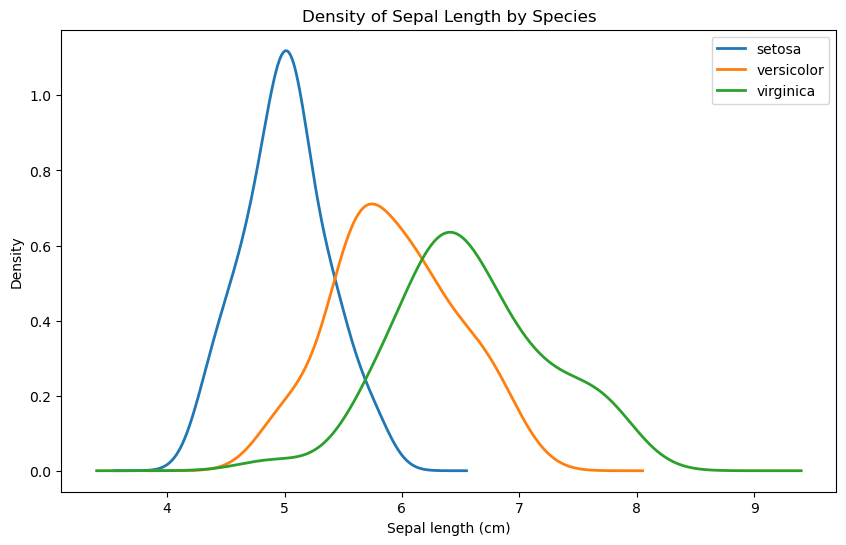

In [9]:

# Density plots of sepal length per species
fig, ax = plt.subplots(figsize=(10, 6))
for sp in species:
    data = iris.loc[iris['species'] == sp, 'sepal_length_cm']
    data.plot(kind='kde', ax=ax, label=sp, linewidth=2)
ax.set_xlabel('Sepal length (cm)')
ax.set_ylabel('Density')
ax.set_title('Density of Sepal Length by Species')
ax.legend()
plt.show()

## 5. Compare the species

Explore how the measurements differ among the three Iris species.

Consider:

- Which measurements differ most visibly by species?
- Which species appear easiest or hardest to distinguish?
- Where is there substantial overlap?
- Which summaries or visualizations help answer these questions?

## 6. Choose useful visualizations

Try visualizations that match the questions you are asking.

Possibilities include histograms, boxplots, scatterplots, bar charts, or a visualization of the correlation matrix.

Think about what each visualization reveals and what it may hide.

## 7. Identify informative attributes

Which attribute, or combination of attributes, appears most useful for distinguishing the Iris species?

Support your answer with evidence from your analysis.

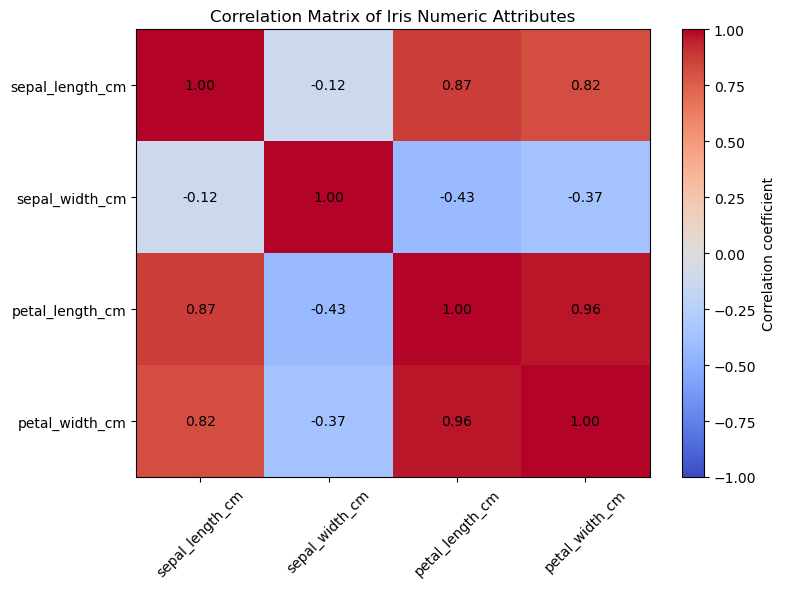

In [16]:
# Compute correlation matrix of the four numeric attributes
numeric_cols = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
corr_matrix = iris[numeric_cols].corr()
# Plot correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label='Correlation coefficient')
# Annotate with values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')
plt.title('Correlation Matrix of Iris Numeric Attributes')
plt.tight_layout()
plt.show()

**Your conclusion:**

## 8. Continue your own investigation

Use the remaining space to investigate any new questions that arose while exploring the data.